# Production Alpha Backtest: Single Spread-Imbalance Strategy

This notebook runs one deterministic hold-to-resolution backtest on PMXT parquet data. It loads market events through `BacktestRunner`, computes orderbook features, applies one fixed spread+imbalance strategy, and reports realized PnL after Polymarket taker fees.

## Execution Contract

1. Run cells top-to-bottom without skipping.
2. Change strategy parameters only in the runtime configuration cell.
3. Treat missing features, missing resolutions, or empty trades as hard failures.
4. Keep strategy logic in helper modules; the notebook should orchestrate only.

## Runtime Setup

In [1]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt

cwd = Path.cwd().resolve()
if (cwd / "config.py").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "config.py").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise RuntimeError("Could not resolve project root containing config.py")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root configured: {PROJECT_ROOT}")

Project root configured: /Users/rahulthaker/Desktop/onlyPositiveAlpha


In [2]:
from collections.abc import Callable
import importlib
import logging

import pandas as pd
from IPython.display import display as ipy_display

from backtester import BacktestConfig, BacktestRunner
from backtester.config.types import FeatureGatePolicy, ValidationPolicy
import backtester.simulation.analytics as analytics
from config import PMXT_DIR
from utils import setup_application_logging

analytics = importlib.reload(analytics)
MetricsTargets = analytics.MetricsTargets
compute_consolidated_metrics = analytics.compute_consolidated_metrics
print_consolidated_metrics_report = analytics.print_consolidated_metrics_report

setup_application_logging()
logger = logging.getLogger(__name__)

print("Imports complete")

Imports complete


In [3]:
# Runtime configuration (edit only this cell)  
RUN_LIMIT_FILES = None
LOOKBACK_HOURS = 2000
MARKET_SAMPLE_SIZE = 1000
MARKET_BATCH_SIZE = 100
USE_FEATURE_CACHE = True

# Prepared dataset controls
USE_PREPARED_BACKTEST_DATASET = True
PREPARED_BACKTEST_DATASET_DIR = PROJECT_ROOT / "data" / "cached" / "pmxt_backtest" / "runs" / "btc-updown-5m"
PREPARED_BACKTEST_MANIFEST = PREPARED_BACKTEST_DATASET_DIR / "manifest.json"

# Optional legacy slug prefix filter (ignored when set to None)
MARKET_SLUG_PREFIX: str | None = None

# Optional artifact output
WRITE_ARTIFACT_PACKAGE = True
ARTIFACT_ROOT = PROJECT_ROOT / "reports" / "artifacts"

# Single strategy parameters (fixed, no calibration search)
# ADJUSTED: Relaxed thresholds for higher signal volume + lower liquidity requirement
IMBALANCE_THRESHOLD = 0.5
SPREAD_WIDE_QUANTILE = 0.6
CONFIDENCE_SCORE_MIN = 1.2
MIN_LIQUIDITY = 5.0

# Quality gates for this single-run workflow
TARGET_WIN_RATE = 0.60
MIN_REQUIRED_TRADES = 6

# Fee model
POLYMARKET_FEE_RATES = {
    "crypto": 0.072,
    "sports": 0.03,
    "finance": 0.04,
    "politics": 0.04,
    "economics": 0.05,
    "culture": 0.05,
    "weather": 0.05,
    "other": 0.05,
    "general": 0.05,
    "mentions": 0.04,
    "tech": 0.04,
    "geopolitics": 0.0,
}
FEE_CATEGORY = "crypto"
FEE_RATE_FALLBACK = 0.072
FEE_RATE = POLYMARKET_FEE_RATES.get(FEE_CATEGORY.strip().lower(), FEE_RATE_FALLBACK)
FEES_ENABLED = True
FEE_PRECISION = 5
MIN_FEE = 0.00001

MAPPING_DIR = PROJECT_ROOT / "data" / "cached" / "mapping"

# Position sizing config
SIZING_POLICY = "risk_budget"
SIZING_RISK_BUDGET_PCT = 0.01  # 1% of capital per trade; supports up to ~100 concurrent 1 USDC entries on 100 capital
AVAILABLE_CAPITAL = 100.0

# Risk constraints calibrated for hold-to-resolution entries.
RISK_MAX_CONCENTRATION_PCT = 1.0
RISK_MAX_ACTIVE_POSITIONS = 100
RISK_MAX_GROSS_EXPOSURE = AVAILABLE_CAPITAL  # Keep gross exposure aligned to available capital (no leverage)

# Helpful visibility into sizing/capacity envelope.
EST_NOTIONAL_PER_TRADE = AVAILABLE_CAPITAL * SIZING_RISK_BUDGET_PCT
EST_MAX_CONCURRENT_BY_GROSS = int(RISK_MAX_GROSS_EXPOSURE // max(EST_NOTIONAL_PER_TRADE, 1e-9))
print(
    "Capacity envelope:"
    f" est_notional_per_trade={EST_NOTIONAL_PER_TRADE:.4f},"
    f" est_max_concurrent_by_gross={EST_MAX_CONCURRENT_BY_GROSS},"
    f" active_position_cap={RISK_MAX_ACTIVE_POSITIONS}"
)

BACKTEST_CONFIG = BacktestConfig(
    mode="tolerant",
    shares=1.0,
    validation_policy=ValidationPolicy(),
    feature_gate_policy=FeatureGatePolicy(),
    order_lifecycle_enabled=True,
    order_ttl_seconds=5,
    order_allow_amendments=True,
    order_max_amendments=1,
    risk_max_active_positions=RISK_MAX_ACTIVE_POSITIONS,
    risk_max_concentration_pct=RISK_MAX_CONCENTRATION_PCT,
    risk_max_gross_exposure=RISK_MAX_GROSS_EXPOSURE,
    enable_progress_bars=True,
    metrics_logging_enabled=True,
    metrics_log_every_n_markets=50,
    retain_full_feature_frames=False,
    retain_strategy_signals=False,
    retain_market_events=False,
    sizing_policy=SIZING_POLICY,
    sizing_risk_budget_pct=SIZING_RISK_BUDGET_PCT,
    available_capital=AVAILABLE_CAPITAL,
)

Capacity envelope: est_notional_per_trade=1.0000, est_max_concurrent_by_gross=100, active_position_cap=100


## Load Data and Compute Features

Load market events from the prepared PMXT backtest dataset, then run a deterministic market sample through feature generation and the full backtest pipeline.

In [4]:
from pathlib import Path
from datetime import UTC, datetime

storage_path = PREPARED_BACKTEST_DATASET_DIR
if not storage_path.exists():
    raise FileNotFoundError(f"Storage path not found: {storage_path}")

runner = BacktestRunner(storage_path=storage_path)
# Prepared shards keep PMXT schema even though the directory name is pmxt_backtest.
runner.is_pmxt_mode = True
manifest_path: Path | None = None
if PREPARED_BACKTEST_MANIFEST.exists():
    manifest_path = PREPARED_BACKTEST_MANIFEST

print(f"Storage path: {storage_path}")
print(f"Manifest path: {manifest_path}")
print(f"Target market sample size: {MARKET_SAMPLE_SIZE}")
print(f"Market batch size: {MARKET_BATCH_SIZE}")

all_markets = runner.load_prepared_feature_market_ids(
    limit_files=RUN_LIMIT_FILES,
    features_manifest_path=manifest_path,
    recursive_scan=True,
)
if not all_markets:
    raise RuntimeError(
        "Prepared feature dataset returned no market IDs. Rebuild prepared dataset first."
    )

if len(all_markets) < MARKET_SAMPLE_SIZE:
    raise RuntimeError(
        f"Only {len(all_markets)} markets available, below requested sample size {MARKET_SAMPLE_SIZE}"
    )

selected_market_ids = all_markets[:MARKET_SAMPLE_SIZE]
selected_market_id_set = set(selected_market_ids)
sampled_market_count = len(selected_market_ids)

print(f"Prepared markets discovered: {len(all_markets)}")
print(
    f"Selected {sampled_market_count} markets for run using deterministic sorted sampling"
)
print(f"Sample market IDs (first 10): {selected_market_ids[:10]}")

2026-04-04 13:40:42 - backtester.runner - INFO - Initialized BacktestRunner with storage path: /Users/rahulthaker/Desktop/onlyPositiveAlpha/data/cached/pmxt_backtest/runs/btc-updown-5m
2026-04-04 13:40:42 - backtester.runner - INFO - Market event path: /Users/rahulthaker/Desktop/onlyPositiveAlpha/data/cached/pmxt_backtest/runs/btc-updown-5m
2026-04-04 13:40:42 - backtester.runner - INFO - Mapping path: /Users/rahulthaker/Desktop/onlyPositiveAlpha/data/cached/pmxt_backtest/runs/mapping
2026-04-04 13:40:42 - backtester.runner - INFO - Feature cache directory: /Users/rahulthaker/Desktop/onlyPositiveAlpha/data/cached/pmxt_backtest/runs/feature_cache
2026-04-04 13:40:42 - backtester.runner - INFO - PMXT mode: False


Storage path: /Users/rahulthaker/Desktop/onlyPositiveAlpha/data/cached/pmxt_backtest/runs/btc-updown-5m
Manifest path: /Users/rahulthaker/Desktop/onlyPositiveAlpha/data/cached/pmxt_backtest/runs/btc-updown-5m/manifest.json
Target market sample size: 1000
Market batch size: 100
Prepared markets discovered: 4595
Selected 1000 markets for run using deterministic sorted sampling
Sample market IDs (first 10): ['0x001c0a542548d0aa8eacfcd07b8dc6e467aabfeb2c3d548f2099a48e357f686d', '0x001dd28330f9787319a1ce1e8b06116a736e01964bb3e4ea67f51e087b69d414', '0x00246a314b8e6671b54cf6e4cfd73c77e3e8c9da3d177381c782acfa903bd181', '0x00254c7cb78deef428f8c2228fa88f9ba23c8ebfdebf26100dccd77fdcda5165', '0x002f9eaa33c6c9d04c1f232acbd1801b6de20769f271a99fce3fc32c9430f936', '0x0048018784542fd8ebd2749f681d9bb4bc530a78b817870643f196478567bbc8', '0x004aff5c484213e8101fc6421b55f585987433e4a958d498bda42271d7b3ef6f', '0x00589896a44527e4d919abe008b8906a3ee5376075ebe6bb3ca5a749d5aaac49', '0x006c587eea49e31246990f9223b0

In [5]:
def build_spread_imbalance_strategy(
    *,
    imbalance_threshold: float,
    spread_wide_quantile: float,
    confidence_score_min: float,
    min_liquidity: float,
) -> Callable[[pd.DataFrame], pd.DataFrame]:
    def _strategy(features: pd.DataFrame) -> pd.DataFrame:
        required_cols = {
            "market_id",
            "token_id",
            "mid_price",
            "spread",
            "imbalance_1",
            "ask_depth_1",
            "ask_depth_5",
            "bid_depth_1",
            "bid_depth_5",
        }
        missing = [col for col in required_cols if col not in features.columns]
        if missing:
            raise ValueError(
                f"Missing required columns for spread+imbalance strategy: {missing}"
            )

        frame = features[
            [
                "market_id",
                "token_id",
                "mid_price",
                "spread",
                "imbalance_1",
                "ask_depth_1",
                "ask_depth_5",
                "bid_depth_1",
                "bid_depth_5",
            ]
        ].copy()
        frame["mid_price"] = pd.to_numeric(frame["mid_price"], errors="coerce")
        frame["spread"] = pd.to_numeric(frame["spread"], errors="coerce")
        frame["imbalance_1"] = pd.to_numeric(frame["imbalance_1"], errors="coerce")
        frame["ask_depth_1"] = pd.to_numeric(frame["ask_depth_1"], errors="coerce")
        frame["bid_depth_1"] = pd.to_numeric(frame["bid_depth_1"], errors="coerce")

        spread_values = frame["spread"].dropna()
        if spread_values.empty:
            raise ValueError("Cannot build strategy without non-null spread values")

        spread_cutoff = spread_values.quantile(spread_wide_quantile)
        frame["liquidity"] = frame[["ask_depth_1", "bid_depth_1"]].fillna(0.0).sum(axis=1)
        frame["confidence_score"] = frame["imbalance_1"].abs() + (
            frame["spread"] / max(spread_cutoff, 1e-9)
        )

        long_mask = (
            (frame["imbalance_1"] >= imbalance_threshold)
            & (frame["spread"] >= spread_cutoff)
            & (frame["confidence_score"] >= confidence_score_min)
            & (frame["liquidity"] >= min_liquidity)
        )
        short_mask = (
            (frame["imbalance_1"] <= -imbalance_threshold)
            & (frame["spread"] >= spread_cutoff)
            & (frame["confidence_score"] >= confidence_score_min)
            & (frame["liquidity"] >= min_liquidity)
        )

        frame["signal"] = 0
        frame.loc[long_mask, "signal"] = 1
        frame.loc[short_mask, "signal"] = -1
        
        # Enforce one-trade-per-market constraint: keep only first occurrence per market
        # Group by market_id and keep only the first row with signal != 0 per market
        frame_with_signal = frame[frame["signal"] != 0].copy()
        if not frame_with_signal.empty:
            # Keep first occurrence per market_id (earliest in sequence)
            frame_with_signal = frame_with_signal.sort_index().drop_duplicates(
                subset=["market_id"], keep="first"
            )
            # Zero out signals for non-first occurrences
            first_indices = frame_with_signal.index
            frame.loc[~frame.index.isin(first_indices), "signal"] = 0
        
        frame.attrs["spread_cutoff"] = float(spread_cutoff)
        frame.attrs["imbalance_threshold"] = float(imbalance_threshold)
        frame.attrs["confidence_score_min"] = float(confidence_score_min)
        frame.attrs["min_liquidity"] = float(min_liquidity)
        frame.attrs["one_trade_per_market_enforced"] = True
        return frame

    return _strategy

In [6]:
production_strategy = build_spread_imbalance_strategy(
    imbalance_threshold=IMBALANCE_THRESHOLD,
    spread_wide_quantile=SPREAD_WIDE_QUANTILE,
    confidence_score_min=CONFIDENCE_SCORE_MIN,
    min_liquidity=MIN_LIQUIDITY,
)

print("Using fixed spread+imbalance parameters:")
print(f"  imbalance_threshold={IMBALANCE_THRESHOLD}")
print(f"  spread_wide_quantile={SPREAD_WIDE_QUANTILE}")
print(f"  confidence_score_min={CONFIDENCE_SCORE_MIN}")
print(f"  min_liquidity={MIN_LIQUIDITY}")

Using fixed spread+imbalance parameters:
  imbalance_threshold=0.5
  spread_wide_quantile=0.6
  confidence_score_min=1.2
  min_liquidity=5.0


In [7]:
result = runner.run_backtest(
    mapping_dir=MAPPING_DIR,
    prepared_manifest_path=manifest_path,
    strategy=production_strategy,
    strategy_name="spread_imbalance_production",
    limit_files=RUN_LIMIT_FILES,
    market_slug_prefix=MARKET_SLUG_PREFIX,
    market_batch_size=MARKET_BATCH_SIZE,
    prepared_feature_market_ids=selected_market_id_set,
    config=BACKTEST_CONFIG,
)

artifact_package_dir = None
if WRITE_ARTIFACT_PACKAGE:
    artifact_package_dir = runner.write_run_artifact_package(
        result,
        output_dir=ARTIFACT_ROOT,
        artifact_version="v1",
    )

print("Single backtest run complete")
print(f"Run ID: {result.metadata.run_id}")
print(f"Mode: {result.metadata.mode}")
print(f"Data window (inferred): {result.metadata.data_window}")
if artifact_package_dir is not None:
    print(f"Artifact package: {artifact_package_dir}")

2026-04-04 13:40:46 - backtester.runner_pipeline - INFO - Backtest batch mode enabled: strategies=1 batch_size=100
2026-04-04 13:40:46 - backtester.runner_pipeline - INFO - Backtest resolution (batch mode): markets=500 diagnostics_rows=0 elapsed=0.01s
backtest: market batches:   0%|          | 0/10 [00:00<?, ?batch/s]2026-04-04 13:40:47 - backtester.loaders.runner_core - INFO - Loaded 627318 prepared feature rows
2026-04-04 13:40:47 - backtester.runner_support - INFO - Trimmed post-resolution rows before feature gates: events=1005 across 16 markets, features=1005 across 16 markets
2026-04-04 13:40:50 - backtester.simulation.execution_engine - INFO - Backtest market progress [spread_imbalance_production]: 50/100 markets | trades=50 | eligible=50 | risk_reject=0 | fill_reject=0 | fill_rate=100.00% | net_pnl=-18.319135
2026-04-04 13:40:50 - backtester.simulation.execution_engine - INFO - Backtest market progress [spread_imbalance_production]: 100/100 markets | trades=100 | eligible=100 | 

Single backtest run complete
Run ID: f6e3ac8afdb742868b5af6d5b748dee3
Mode: tolerant
Data window (inferred): {'start': None, 'end': None}
Artifact package: /Users/rahulthaker/Desktop/onlyPositiveAlpha/reports/artifacts/v1/f6e3ac8afdb742868b5af6d5b748dee3


In [8]:
resolution_frame = result.resolution_frame
resolution_diagnostics = result.resolution_diagnostics
trade_ledger = result.trade_ledger
order_ledger = result.order_ledger
backtest_summary = result.backtest_summary
equity_curve = result.equity_curve
strategy_signals = result.strategy_signals
feature_health = result.feature_health
data_quality_report = result.data_quality_report
error_ledger = result.error_ledger
settlement_repair_audit = result.settlement_repair_audit
diagnostics_by_market = result.diagnostics_by_market
diagnostics_by_regime = result.diagnostics_by_regime
cache_metadata = result.cache_metadata

if trade_ledger.empty:
    raise RuntimeError(
        "No trades were generated. Relax thresholds, expand lookback, or verify mapping coverage."
    )

strategy_name = backtest_summary.iloc[0]["strategy"]
strategy_signal_frame = strategy_signals[strategy_name]
win_rate = float(backtest_summary.iloc[0]["win_rate"])
trades = int(backtest_summary.iloc[0]["trades"])
net_pnl = float(backtest_summary.iloc[0]["net_pnl"])

print(f"Strategy: {strategy_name}")
print(f"Resolved markets available: {len(resolution_frame)}")
print(f"Validated markets: {len(resolution_diagnostics)}")
print(f"Generated {len(trade_ledger)} closed trades")
print(f"Win rate: {win_rate:.1%} across {trades} trades")
print(f"Net PnL: {net_pnl:.4f}")
print(f"Cache metadata: {cache_metadata}")
print(f"Data quality issues: {len(data_quality_report)}")
print(f"Feature health rows: {len(feature_health)}")
print(f"Error ledger rows: {len(error_ledger)}")
print(f"Settlement repair audit rows: {len(settlement_repair_audit)}")

if trades < MIN_REQUIRED_TRADES:
    print(
        f"WARNING: Only {trades} trades generated, below minimum {MIN_REQUIRED_TRADES}. "
        "Expand lookback window or loosen entry thresholds."
    )
if net_pnl <= 0.0:
    print(
        f"WARNING: Net PnL {net_pnl:.4f} is non-positive. Recalibrate threshold grid or fill assumptions."
    )
if win_rate < TARGET_WIN_RATE:
    print(
        f"WARNING: Win rate {win_rate:.1%} is below target {TARGET_WIN_RATE:.0%}. "
        "Adjust fixed strategy thresholds or match target to current market regime."
    )

ipy_display(backtest_summary)

Strategy: spread_imbalance_production
Resolved markets available: 500
Validated markets: 0
Generated 110 closed trades
Win rate: 42.7% across 110 trades
Net PnL: -18.4520
Cache metadata: {'cache_signature': 'bff9cb90f0c8e0f8', 'cache_schema_version': 'v1', 'cache_computation_signature': 'orderbook_core_v1'}
Data quality issues: 0
Feature health rows: 80
Error ledger rows: 17
Settlement repair audit rows: 0


,strategy,trades,wins,win_rate,gross_pnl,net_pnl,fees,avg_gross_pnl,avg_net_pnl,avg_hold_hours,avg_gross_return_pct,avg_net_return_pct,fee_drag_pct,run_id
0,spread_imbalance_production,110,47,0.427273,-14.490266,-18.451962,3.96144,-0.13173,-0.167745,0.134174,-0.13173,-0.167745,0.036013,f6e3ac8afdb742868b5af6d5b748dee3


FINAL CONSOLIDATED METRICS

Consolidated metrics table:


,strategy,trades,wins,win_rate,gross_pnl,net_pnl,fees,avg_gross_pnl,avg_net_pnl,avg_hold_hours,...,total_return_pct,sharpe_ratio,sortino_ratio,max_drawdown_pct,calmar_ratio,num_trades,win_rate_pct,profit_factor,initial_capital,final_capital
0,spread_imbalance_production,100,74,0.74,49.4401,45.8055,3.6346,0.4944,0.4581,0.3592,...,45.8055,0.4738,inf,-2.9121,15.7296,100,74.0,2.7,100.0,145.8055



Validation checks table:


,strategy,check,passed,value
0,spread_imbalance_production,trades >= 150,False,100.000000
1,spread_imbalance_production,win_rate >= 60%,True,0.740000
2,spread_imbalance_production,sharpe >= 0.5,False,0.473767
3,spread_imbalance_production,abs(max_drawdown_pct) <= 25.0,True,-2.912067
4,spread_imbalance_production,capital_preserved > 50,True,145.805521



Order state table:


,state,count
0,submitted,113
1,filled,100
2,rejected,13


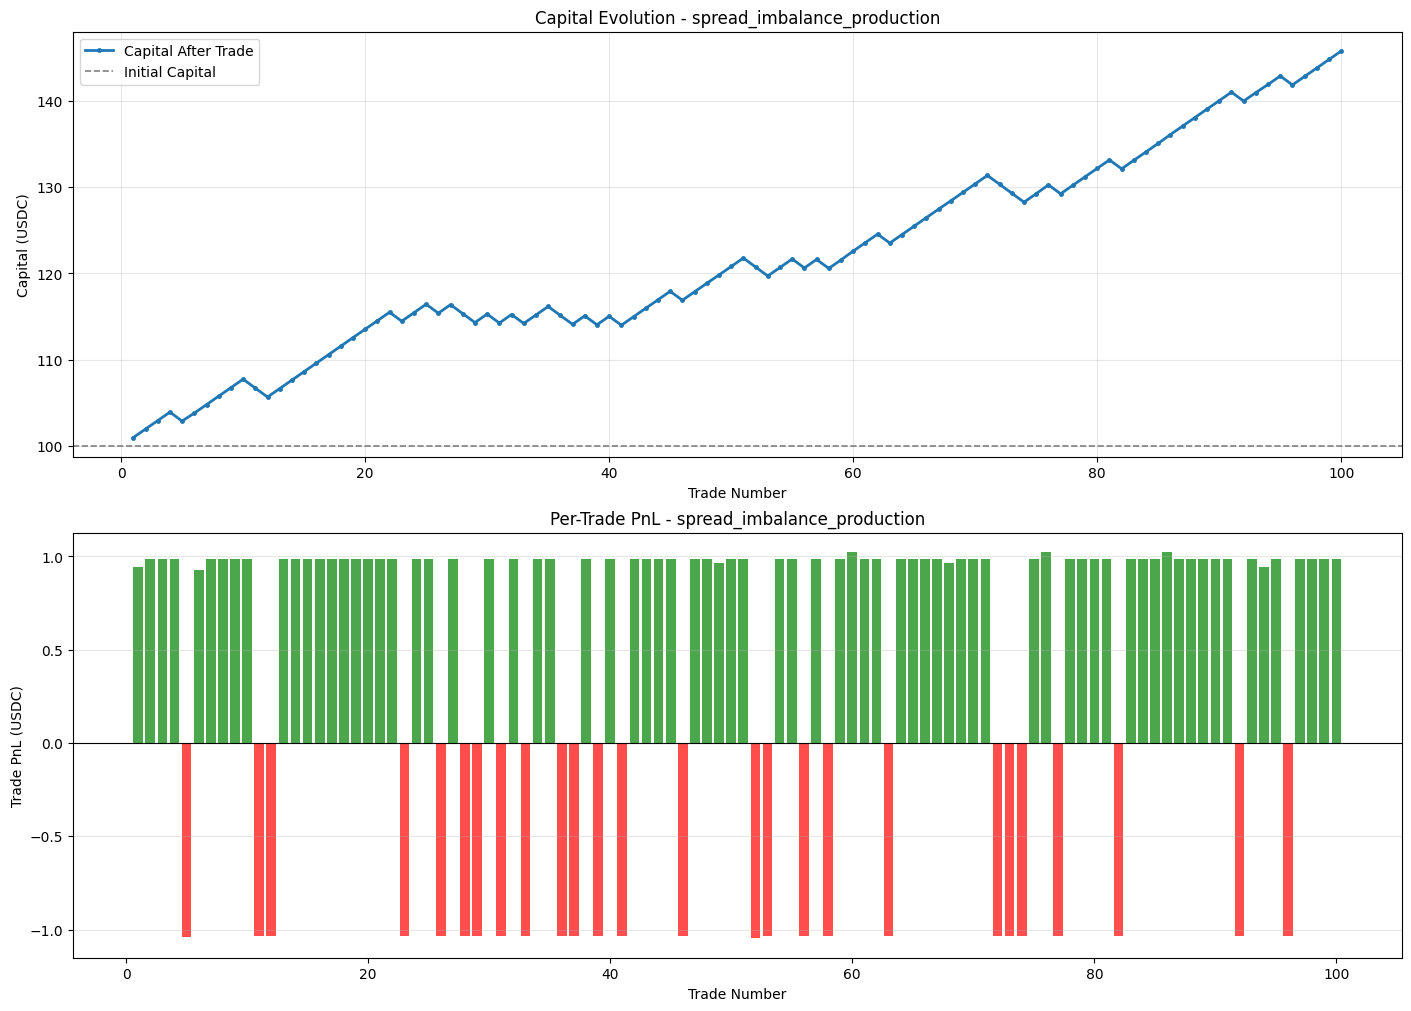

In [21]:
import math

print("=" * 80)
print("FINAL CONSOLIDATED METRICS")
print("=" * 80)

initial_capital = float(getattr(BACKTEST_CONFIG, "available_capital", None) or 100.0)
plot_max_points = 1200

metrics_bundle = compute_consolidated_metrics(
    backtest_summary=backtest_summary,
    trade_ledger=trade_ledger,
    order_ledger=order_ledger,
    equity_curve=equity_curve,
    initial_capital=initial_capital,
    targets=MetricsTargets(
        min_trades=150,
        min_win_rate=0.60,
        min_sharpe=0.5,
        max_drawdown_pct=25.0,
    ),
)

consolidated_metrics = metrics_bundle["consolidated_metrics"]
validation_checks = metrics_bundle["validation_checks"]
capital_evolution_df = metrics_bundle["capital_evolution"]
order_state = metrics_bundle["order_state"]

if not consolidated_metrics.empty:
    print("\nConsolidated metrics table:")
    ipy_display(consolidated_metrics.round(4))

if not validation_checks.empty:
    print("\nValidation checks table:")
    ipy_display(validation_checks)

if not order_state.empty:
    print("\nOrder state table:")
    ipy_display(order_state)

if not capital_evolution_df.empty:
    for strategy_name in capital_evolution_df["strategy"].dropna().unique().tolist():
        strategy_capital = capital_evolution_df[
            capital_evolution_df["strategy"] == strategy_name
        ].copy()
        strategy_capital = strategy_capital.sort_values("trade_num")

        plot_capital = strategy_capital
        if len(strategy_capital) > plot_max_points:
            step = max(1, math.ceil(len(strategy_capital) / plot_max_points))
            plot_capital = strategy_capital.iloc[::step].copy()
            print(
                f"Downsampled capital plot for {strategy_name}: "
                f"{len(strategy_capital)} -> {len(plot_capital)} points"
            )

        fig, axes = plt.subplots(2, 1, figsize=(14, 10), constrained_layout=True)

        ax1 = axes[0]
        ax1.plot(
            plot_capital["trade_num"],
            plot_capital["post_trade_capital"],
            label="Capital After Trade",
            linewidth=2.0,
            marker="o",
            markersize=2.5,
        )
        ax1.axhline(
            y=initial_capital,
            color="gray",
            linestyle="--",
            linewidth=1.2,
            label="Initial Capital",
        )
        ax1.set_xlabel("Trade Number")
        ax1.set_ylabel("Capital (USDC)")
        ax1.set_title(f"Capital Evolution - {strategy_name}")
        ax1.grid(True, alpha=0.3)
        ax1.legend(loc="best")

        ax2 = axes[1]
        bar_colors = [
            "green" if pnl > 0 else "red"
            for pnl in plot_capital["net_pnl"].tolist()
        ]
        ax2.bar(
            plot_capital["trade_num"],
            plot_capital["net_pnl"],
            color=bar_colors,
            alpha=0.7,
        )
        ax2.axhline(y=0.0, color="black", linestyle="-", linewidth=0.8)
        ax2.set_xlabel("Trade Number")
        ax2.set_ylabel("Trade PnL (USDC)")
        ax2.set_title(f"Per-Trade PnL - {strategy_name}")
        ax2.grid(True, alpha=0.3, axis="y")

        plt.show()
        plt.close(fig)